<a href="https://colab.research.google.com/github/Blevins05/data-ai-summer2026/blob/main/visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Visualización de datos en partidos LaLiga 19/25

En el área del aprendizaje automático, la *visualización de datos* no es sólo una manera de preparar gráficos para los informes, sino que se utiliza en distintas fases de los proyectos.

Para empezar, la exploración visual de los datos es lo primero que se tiende a hacer cuando se aborda una nueva tarea. A través de gráficas y tablas es posible resumir los datos y eliminar aquellos que no son relevantes para la tarea a abordar. Para las personas, los resúmenes de datos en tablas y gráficas son mucho más legibles que cientos de líneas de datos.

La visualización de datos también se utiliza para analizar el rendimiento de un modelo, ya que para interpretar modelos complejos se hace necesario proyectar espacios de alta dimensionalidad en gráficos 2D o 3D.

En resumen, la visualización de datos es una manera rápida de aprender algo nuevo sobre los datos con los que se está trabajando.

In [1]:
!pip install seaborn -Uq

A continuación importamos las librerías que usaremos en este parte de la práctica.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# La siguiente línea se utiliza para generar los gráficos en formato SVG los cuales son más legibles.
%config InlineBackend.figure_format = 'svg'

El dataset que utilizo es un dataset sobre partidos de LaLiga, durante las temporadas 2019-2025

In [3]:
df = pd.read_csv("matches_laliga.csv")

Para repasar un poco el análisis básico en pandas, empiezo mostrando algunas características sobre los datos

In [4]:
df.head()

,Unnamed: 0,date,time,comp,round,day,venue,result,gf,ga,...,match report,notes,sh,sot,dist,fk,pk,pkatt,season,team
0,0,2025-08-16,19:30,La Liga,Matchweek 1,Sat,Away,W,3.0,0.0,...,Match Report,NaN,24.0,8.0,18.9,1.0,0,0,2025,Barcelona
1,1,2025-08-23,21:30,La Liga,Matchweek 2,Sat,Away,W,3.0,2.0,...,Match Report,NaN,26.0,10.0,17.0,1.0,0,0,2025,Barcelona
2,2,2025-08-31,21:30,La Liga,Matchweek 3,Sun,Away,D,1.0,1.0,...,Match Report,NaN,11.0,2.0,20.3,0.0,1,1,2025,Barcelona
3,3,2025-09-14,21:00,La Liga,Matchweek 4,Sun,Home,W,6.0,0.0,...,Match Report,NaN,24.0,10.0,18.4,0.0,0,0,2025,Barcelona
4,5,2025-09-21,21:00,La Liga,Matchweek 5,Sun,Home,W,3.0,0.0,...,Match Report,NaN,16.0,7.0,18.2,2.0,0,0,2025,Barcelona


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4700 entries, 0 to 4699
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     4700 non-null   int64  
 1   date           4700 non-null   object 
 2   time           4700 non-null   object 
 3   comp           4700 non-null   object 
 4   round          4700 non-null   object 
 5   day            4700 non-null   object 
 6   venue          4700 non-null   object 
 7   result         4700 non-null   object 
 8   gf             4700 non-null   float64
 9   ga             4700 non-null   float64
 10  opponent       4700 non-null   object 
 11  xg             4700 non-null   float64
 12  xga            4700 non-null   float64
 13  poss           4700 non-null   float64
 14  attendance     3724 non-null   float64
 15  captain        4700 non-null   object 
 16  formation      4700 non-null   object 
 17  opp formation  4700 non-null   object 
 18  referee 

In [6]:
df.describe()

,Unnamed: 0,gf,ga,xg,xga,poss,attendance,notes,sh,sot,dist,fk,pk,pkatt,season
count,4700.000000,4700.000000,4700.000000,4700.000000,4700.000000,4700.000000,3724.000000,0.0,4700.000000,4700.000000,4697.000000,4700.000000,4700.000000,4700.000000,4700.000000
mean,22.061702,1.273617,1.273617,1.264532,1.264532,50.001064,28097.842105,NaN,11.550213,3.804468,18.154652,0.443191,0.130426,0.168936,2021.604255
std,14.395784,1.165048,1.165048,0.776251,0.776251,11.509529,18104.760706,NaN,4.906037,2.296370,3.386085,0.688555,0.362374,0.415661,1.784514
min,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,13.000000,NaN,0.000000,0.000000,4.800000,0.000000,0.000000,0.000000,2019.000000
25%,9.000000,0.000000,0.000000,0.700000,0.700000,42.000000,14266.000000,NaN,8.000000,2.000000,15.900000,0.000000,0.000000,0.000000,2020.000000
50%,22.000000,1.000000,1.000000,1.100000,1.100000,50.000000,20298.500000,NaN,11.000000,3.000000,18.000000,0.000000,0.000000,0.000000,2022.000000
75%,34.000000,2.000000,2.000000,1.700000,1.700000,58.000000,39957.000000,NaN,14.000000,5.000000,20.000000,1.000000,0.000000,0.000000,2023.000000
max,60.000000,7.000000,7.000000,5.900000,5.900000,82.000000,95745.000000,NaN,40.000000,17.000000,46.200000,5.000000,3.000000,3.000000,2025.000000


### 2. Visualización Univariante


El análisis univariante se centra en un descriptor cada vez. Cuando analizamos un descriptor de manera independiente estamos interesados principalmente en conocer la *distribución de sus valores* e ignoramos el resto de descriptores del dataset.

A continuación se consideran distintos tipos de análisis de una variable.


#### 2.1 Descriptores cuantitativos

Los descriptores cuantitativos se aplican a valores numéricos. Dichos valores pueden ser *discretos*, como los enteros, o *continuos*, como los reales, y suelen expresar una contabilización o medida.

*Histogramas y gráficos de densidad*

La manera más sencilla de ver la distribución de una variable númerica consiste en mostrar su *histograma*, para ello podemos usar el método [`hist()`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.hist.html) de un `DataFrame`.

array([[<Axes: title={'center': 'gf'}>]], dtype=object)

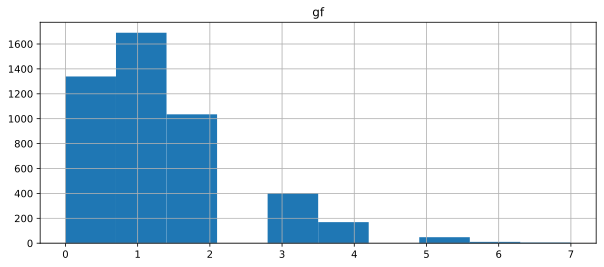

In [10]:
features = ["gf"]
df[features].hist(figsize=(10,4))

Un histograma agrupa los valores en cajas, o *bins*, de rangos de valores. La forma del histograma puede contener pistas sobre la distribución subyacente: Gaussiana, exponencial, etc. Con los histogramas también es posible detectar anomalías. Conocer la distribución de los descriptores es importante debido a que la mayoría de algoritmos de aprendizaje automático asumen que tienen un tipo particular (normalmente una Gaussiana).

En el gráfico anterior, vemos que la variable *Total day minutes* sigue una distribución normal, mientras que  *Total intl calls* está desviada hacia la derecha (su cola es más larga en el lado derecho).


*Gráficos de densidad*

También hay otra manera, muchas veces más clara, de ver las distribuciones y son los gráficos de densidad. Estos pueden verse como una versión [suavizada](https://en.wikipedia.org/wiki/Kernel_smoother) de los histogramas. Su principal ventaja es que no tienen una dependencia con el tamaño de las *bins*. Vamos a ver cómo se crean estos diagramas para las mismas dos variables que antes.

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>]], dtype=object)

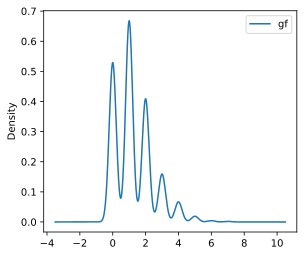

In [12]:
df[features].plot(kind="density", subplots=True, layout=(1,2), sharex=False, figsize=(10,4))

También es posible mostrar la distribución de las observaciones con el método [`histplot()`](https://seaborn.pydata.org/generated/seaborn.histplot.html) de la librería seaborn. Por ejemplo, vamos a ver la distribución para la variable  *Total intl calls*.

<Axes: ylabel='Density'>

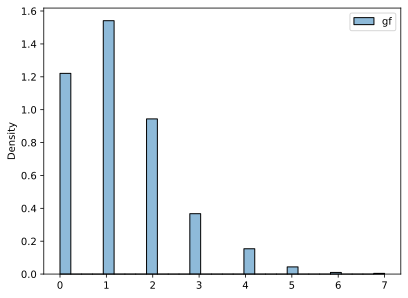

In [13]:
sns.histplot(df[features], stat="density")

La altura de cada barra del histograma muestra la densidad en lugar del número de ejemplos en cada bin.

<Axes: xlabel='gf'>

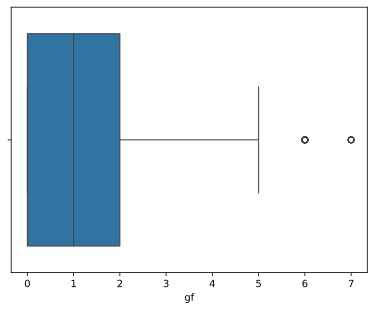

In [14]:
sns.boxplot(x="gf", data=df)

Veámos cómo interpretar el gráfico anterior. Sus componentes son una caja (que es por lo que se conoce a este tipo de gráficos como gráficos de cajas), los *bigotes*, y un número de puntos (conocidos como *outliers* o valores atípicos).

La caja muestra la extensión intercuartil de la distribución, su longitud viene dada por los percentiles $25 \, (\text{Q1})$ y $75 \, (\text{Q3})$. La línea vertical en la caja muestra la mediana de la distribución.

Los bigotes son las líneas horizontales que salen de la caja. Estas representan la dispersión completa de los puntos de datos, específicamente los puntos que caen en el intervalo $(\text{Q1} - 1.5 \cdot \text{IQR}, \text{Q3} + 1.5 \cdot \text{IQR})$, donde $\text{IQR} = \text{Q3} - \text{Q1}$ es el [rango intercuartílico](https://es.wikipedia.org/wiki/Rango_intercuart%C3%ADlico).

Los valores atípicos caen fuera del rango definido por los bigotes y se muestran como puntos individuales.

A partir del gráfico anterior podemos ver que es raro que haya un gran número de llamadas internacionales en nuestros datos.

#### Explicación de los parámetros de `sns.boxplot()`

El método [`seaborn.boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html) se utiliza para dibujar diagramas de caja para visualizar la distribución de datos numéricos. En la celda `brFK6H-gHs-i`, se usa con los siguientes parámetros:

*   **`x='gf'`**: Este parámetro especifica la variable que se utilizará para el eje x. En este caso, es la columna `'gf'` (Goles a favor) del DataFrame `df`.

*   **`y=feat`**: Este parámetro especifica la variable que se utilizará para el eje y. `feat` es una variable que toma sucesivamente los nombres de las columnas definidas en `cols` (`'gf'`, `'ga'`, `'xg'`, `'xga'`, `'poss'`, `'sh'`, `'sot'`, `'dist'`). Esto crea un diagrama de caja para cada una de estas variables, mostrando su distribución con respecto a `'gf'` en el eje x.

*   **`data=df`**: Este parámetro indica el DataFrame de Pandas del que se tomarán los datos. En este caso, es el DataFrame `df` cargado previamente.

*   **`ax=ax`**: Este parámetro asigna el gráfico a un objeto `Axes` específico. En el código, `ax` es un objeto `Axes` que se obtiene de una subtrama creada con `plt.subplots()`, lo que permite organizar múltiples gráficos en una sola figura.

*Gráficos de violines*

El último tipo de gráfico de distribución que vamos a ver son los gráficos de violines.

En la figura de abajo podemos ver un gráfico de violines. En la parte izquierda vemos el ya familiar gráfico de cajas, mientras que en la derecha vemos el gráfico de violínes donde de ha estimado la densidad del núcleo en ambos lados.

<Axes: ylabel='gf'>

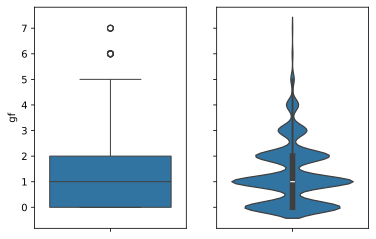

In [21]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(6, 4))
# con esto se crea la estructura donde van a ir ambos plots
sns.boxplot(data=df['gf'], ax=axes[0])
sns.violinplot(data=df['gf'], ax=axes[1])

También es posible utilizar el método `describe()` para obtener una serie de estadisticas de la distribución de algunos descriptores

In [24]:
features = ['gf', 'ga']
df[features].describe()

,gf,ga
count,4700.000000,4700.000000
mean,1.273617,1.273617
std,1.165048,1.165048
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,7.000000,7.000000


La salida anterior es autoexplicativa. Los valores *25%*, *50%* y *75%* muestran los correspondientes [percentiles](https://es.wikipedia.org/wiki/Percentil).

#### 2.2 Datos categóricos y binarios

Los descriptores categóricos toman un número fijo de valores. Cada uno de estos valores asigna una observación al grupo correspondiete, cada grupo se conoce como categoría. Los descriptores binarios son un caso particular de los descriptores categóricos que solo toman dos posibles valores. Si los valores categóricos tienen un orden, se los conoce como ordinales.

*Tabla de frecuencias*

Veámos el balance de clases en nuestro dataset mirando la distribución de la variable *formation*. Para ello vamos a considerar la tabla de frecuencias que muestra como de frecuente es cada valor categórico. Para ello usamos el método [`value_counts()`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.value_counts.html):

In [25]:
df['formation'].value_counts()

,count
formation,
4-4-2,1298
4-2-3-1,1194
4-3-3,750
4-1-4-1,321
5-3-2,277
3-4-3,219
5-4-1,127
3-5-2,98
4-1-3-2,98


*Gráfico de barras*

El gráfico de barras es literalmente una representación gráfica de la tabla de frecuencias. La manera más fácil de crearlo es usando la función  [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) de seaborn.

Vamos a mostrar la distribución para dos descriptores categóricos.

<Axes: xlabel='poss', ylabel='count'>

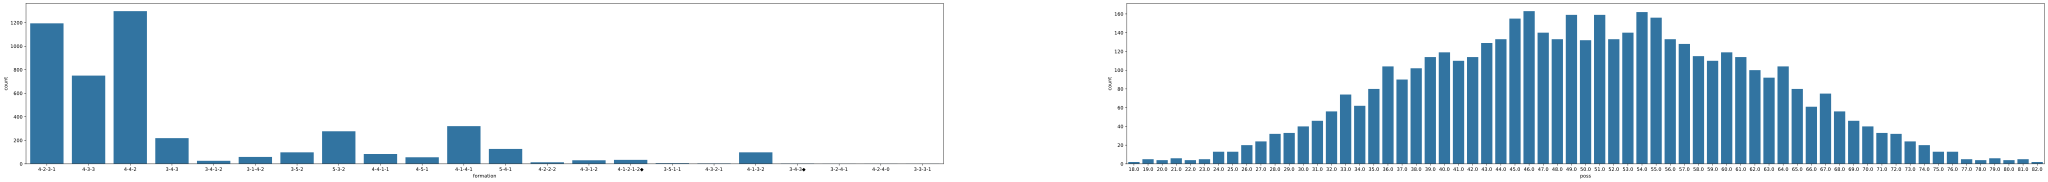

In [36]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(75, 6))
sns.countplot(x='formation', data=df, ax=axes[0])
sns.countplot(x='poss', data=df, ax=axes[1])

Aunque los histogramas y las gráficas de cajas puedean parecer similares hay varias diferencias entre ellas.
1. Los histogramas se utilizan para mostrar la distribución de descriptores numéricos mientras que los gráficos de cajas se usan para descriptores categóricos.
2. Los valores del eje X en el histograma son numéricos mientras que en el diagrama de cajas puede haber cualquier tipo de valor (números, strings, booleanos).

### 3. Visualización multivariante

Los gráficos multivariantes permiten mostrar relaciones entre dos o más descriptores en una única figura. Como en el caso de los gráficos univariantes el tipo específico de visualización dependerá del tipo de descriptor con el que estemos trabajando.


#### 3.1 Cuantitativo-Cualitativo

*Matriz de correlación*

Vamos a ver la correlación entre valores númericos de nuestro dataset. Esta información es importante ya que hay algoritmos de aprendizaje automático que no trabajan bien con variables altamente correladas.

Vamos a utilizar en primer lugar el método [`corr()`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.corr.html) en un `DataFrame` que sirve para calcular la correlación entre dos pares de descriptores. Este valor, la matriz de correlación, se le puede pasar al método [`heatmap()`](https://seaborn.pydata.org/generated/seaborn.heatmap.html) de `seaborn` para mostrar una matriz de colores con los valores proporcionados.

Primero, comienzo definiendo aquellos descriptores o stats que me interesan

In [39]:
cols = ['gf', 'ga', 'xg', 'xga', 'poss', 'sh', 'sot', 'dist']

<Axes: >

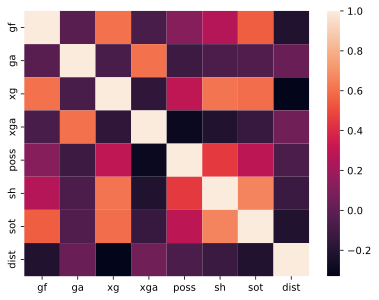

In [41]:
corr_matrix = df[cols].corr()
sns.heatmap(corr_matrix)

Gracias a esto, podemos conocer cual es la correlación entre 2 pares de descriptores existentes en el dataset.

*Diagrama de dispersión*

Los diagramas de dispersión muestran los valores de dos descriptores numéricos en las coordenadas Cartesianas de un espacio 2D. También es posible mostrar diagramas de dispersión en 3D.

Para mostrar los diagramas de dispersión usaremos el método [`scatter()`](https://matplotlib.org/devdocs/api/_as_gen/matplotlib.pyplot.scatter.html) de la librería `matplotlib`:

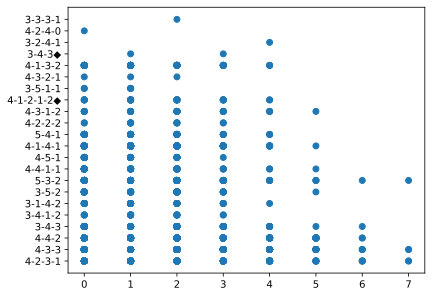

In [44]:
plt.scatter(df['gf'], df['formation'])

También es posible mostrar estos gráficos de dispersión utilizando el método `jointplot()`

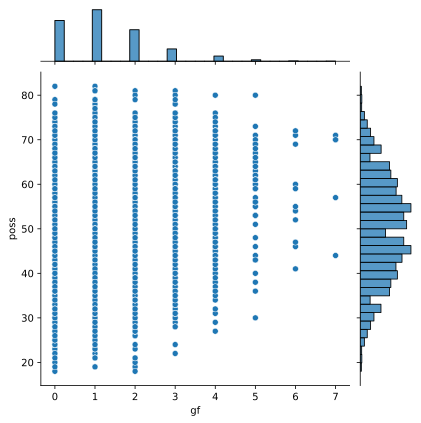

In [45]:
sns.jointplot(x="gf", y="poss", kind='scatter', data=df)

*Matriz de diagramas de dispersión*

En algunos caos, resulta útil mostrar una matriz de diagramas de dispersión como se muestra a continuación. La diagonal de dicha matriz contiene las distribuciones de los correspondientes descriptores, miesntras que los diagramas de dispersión para cada par de descriptores rellenan el resto de la matriz.

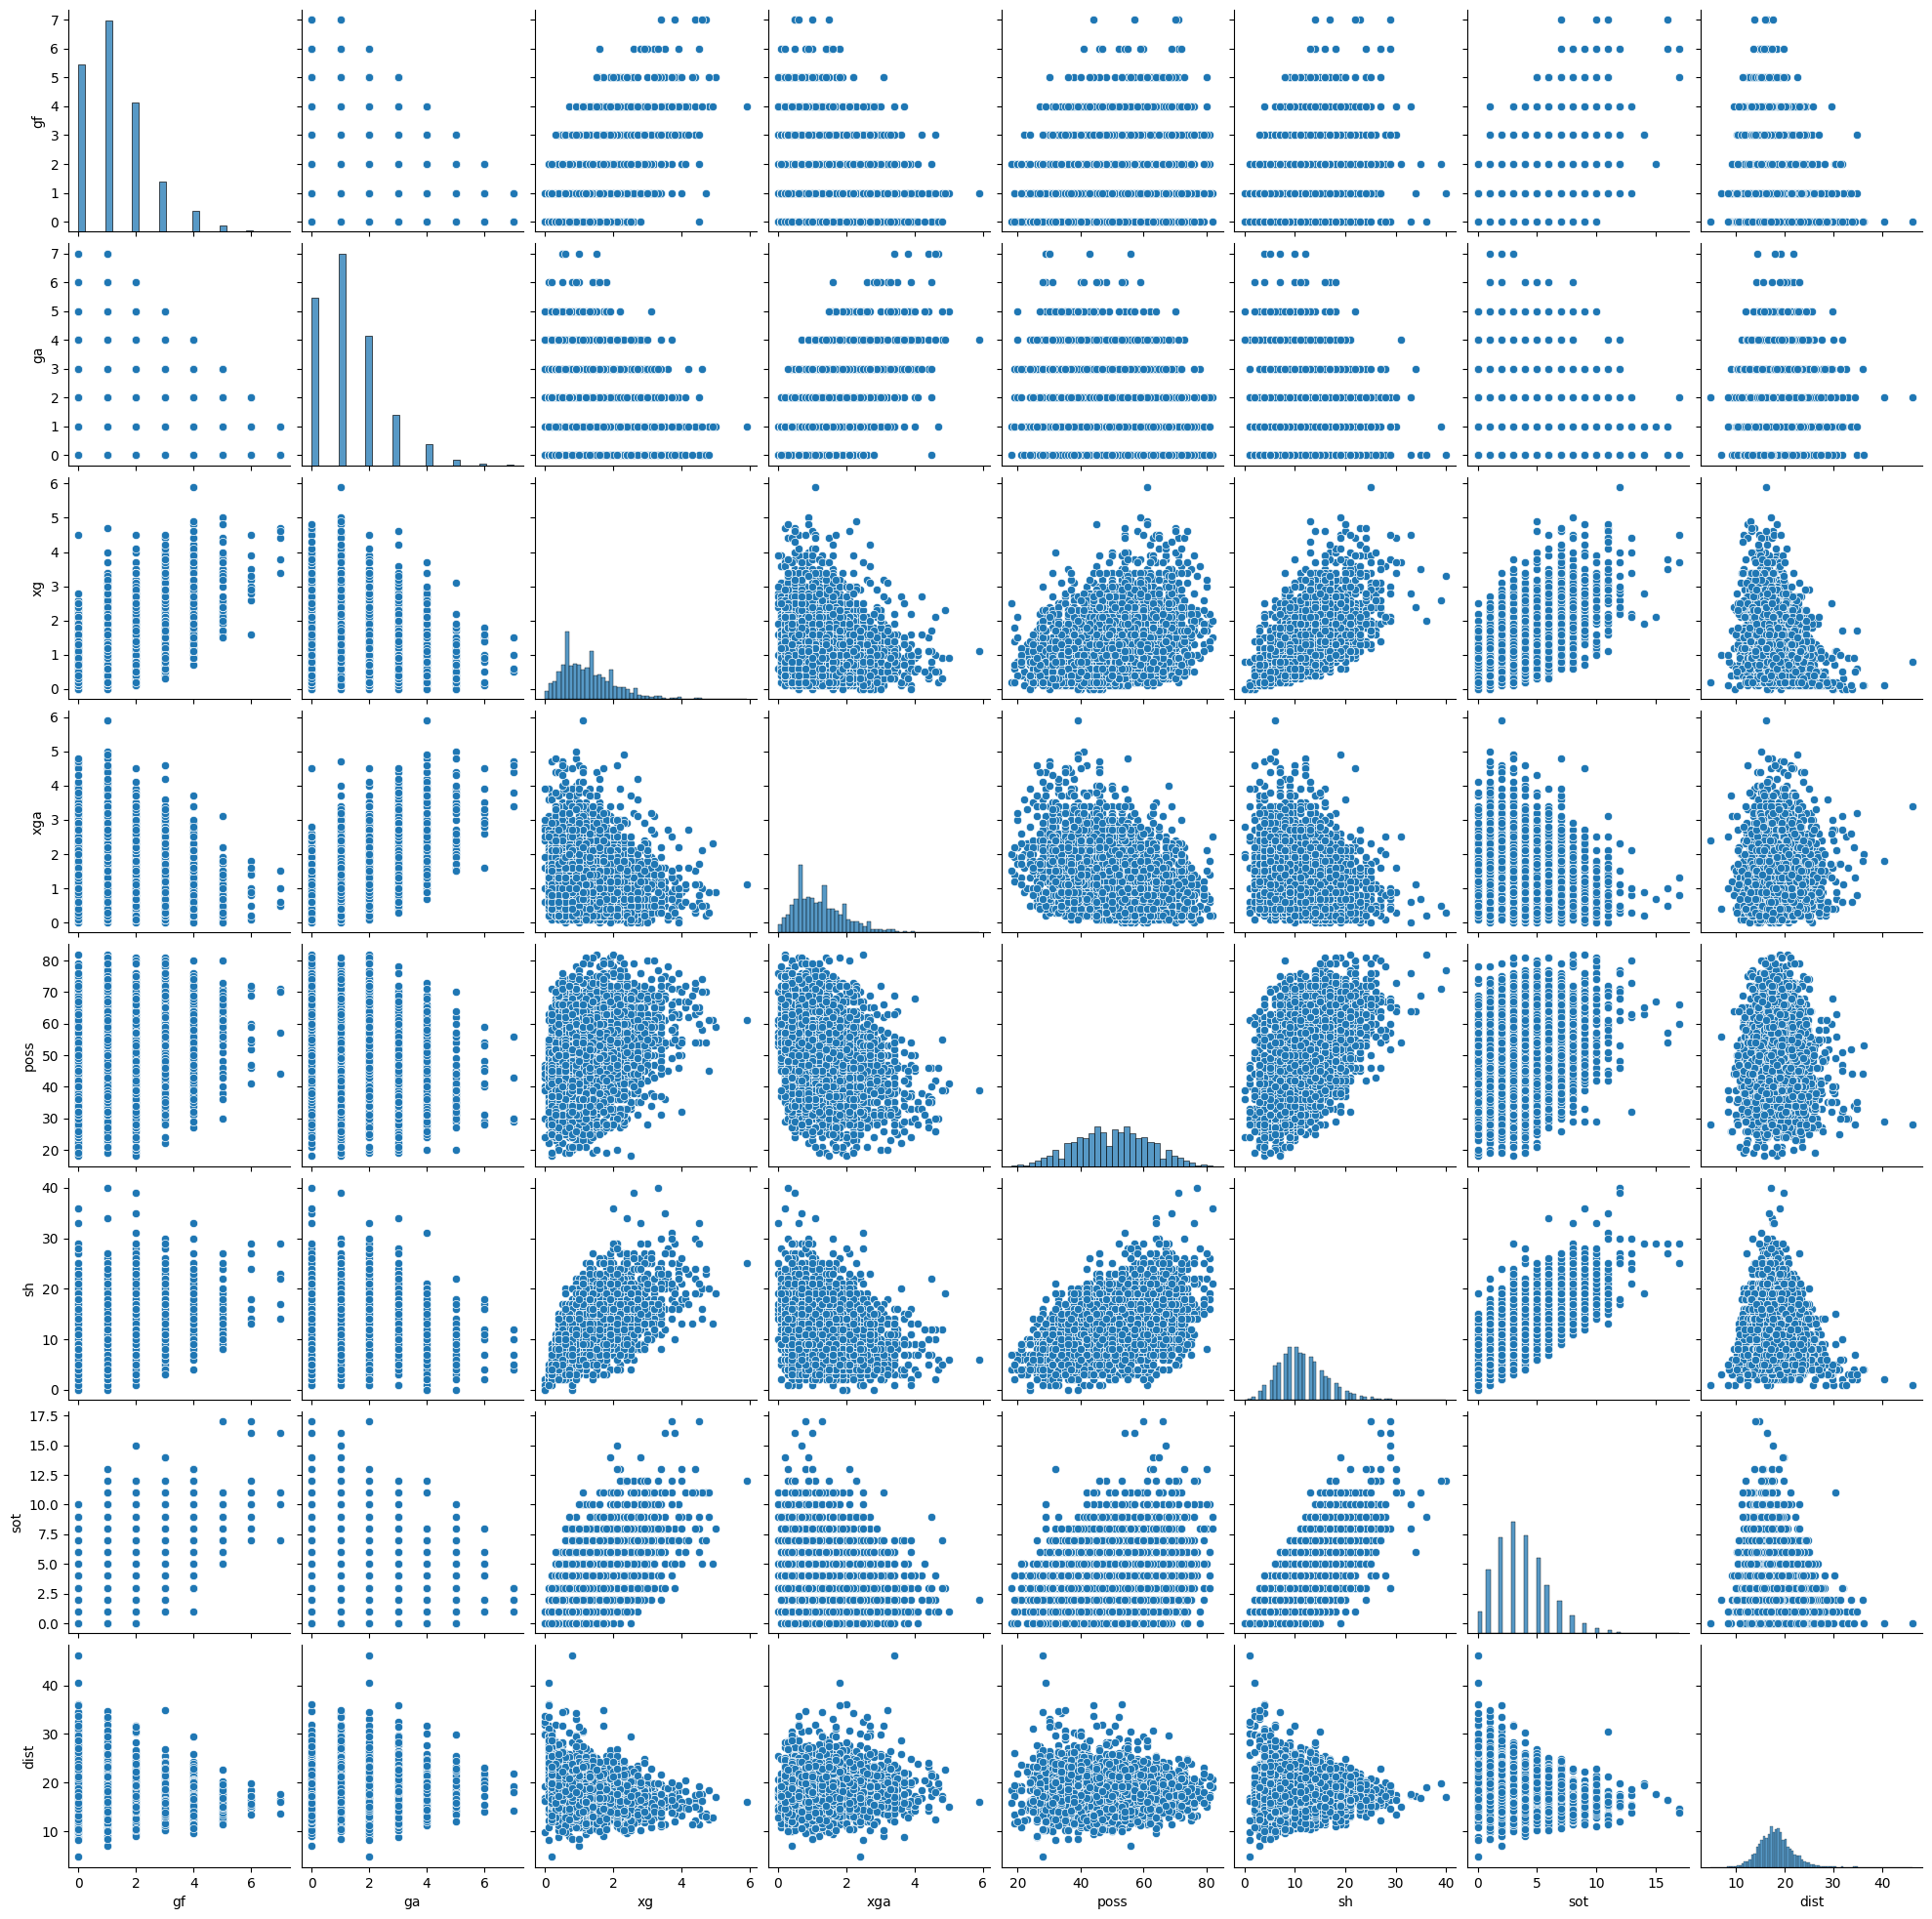

In [47]:
# Cambiamos la configuración a png ya que la generación de diagramas con SVG puede ser muy lenta en este caso
%config InlineBackend.figure_format = 'png'
sns.pairplot(df[cols]);

In [48]:
# Volvemos a cambiar la configuración
%config InlineBackend.figure_format = 'svg'

#### 3.2 Cuantitativo-Categórico

Anteriormente hemos visto los gráficos de dispersión. De manera adicional, los puntos de dichos diagramas se pueden codificar con colores o tamaños para incluir los valores de un tercer descriptor categórico en la misma figura. Esto se puede conseguir con la función `scatter()`, pero vamos a usar la función [`lmplot()`](https://seaborn.pydata.org/generated/seaborn.lmplot.html) y el parámetro `hue` para indicar el descriptor de interés.

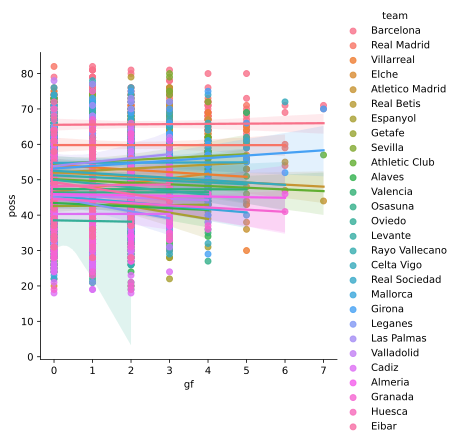

In [49]:
sns.lmplot(x='gf', y='poss', hue='team', data=df)

#### Explicación de los parámetros de `sns.lmplot()`

El método [`seaborn.lmplot()`](https://seaborn.pydata.org/generated/seaborn.lmplot.html) es una función muy útil de Seaborn que combina `regplot()` y `FacetGrid` para crear gráficos de dispersión con líneas de regresión, facilitando la visualización de relaciones entre variables, y permitiendo la división de la gráfica en subgráficas (facets) basadas en variables categóricas. En la celda `vQ6f05jBHlwu`, se usa con los siguientes parámetros:

*   **`x='gf'`**: Este parámetro especifica la variable numérica para el eje horizontal (eje x). En este caso, se utiliza la columna `'gf'` (Goles a favor) del DataFrame `df`.

*   **`y='poss'`**: Este parámetro especifica la variable numérica para el eje vertical (eje y). Aquí, se utiliza la columna `'poss'` (Posesión de balón) del DataFrame `df`.

*   **`hue='team'`**: Este es un parámetro clave para la visualización multivariante. `hue` toma una variable categórica (`'team'` en este caso) y representa diferentes categorías con colores distintos en el gráfico. Esto permite ver cómo la relación entre `gf` y `poss` varía para cada equipo.

*   **`data=df`**: Este parámetro indica el DataFrame de Pandas del que se tomarán los datos para todas las variables especificadas (`x`, `y`, `hue`). En este caso, es el DataFrame `df` cargado previamente.

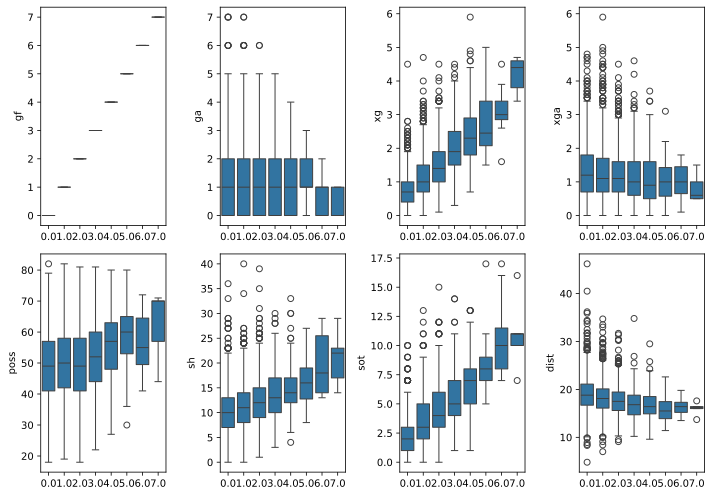

In [51]:

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(10, 7))
for idx, feat in enumerate(cols):
    ax = axes[int(idx / 4), idx % 4]
    sns.boxplot(x='gf', y=feat, data=df, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel(feat)
fig.tight_layout();

Cuando queremos realizar una análisis cuantitativo de un descriptor en dos dimensiones a la vez, existe una función llamada [`catplot()`](https://seaborn.pydata.org/generated/seaborn.factorplot.html) en seaborn.

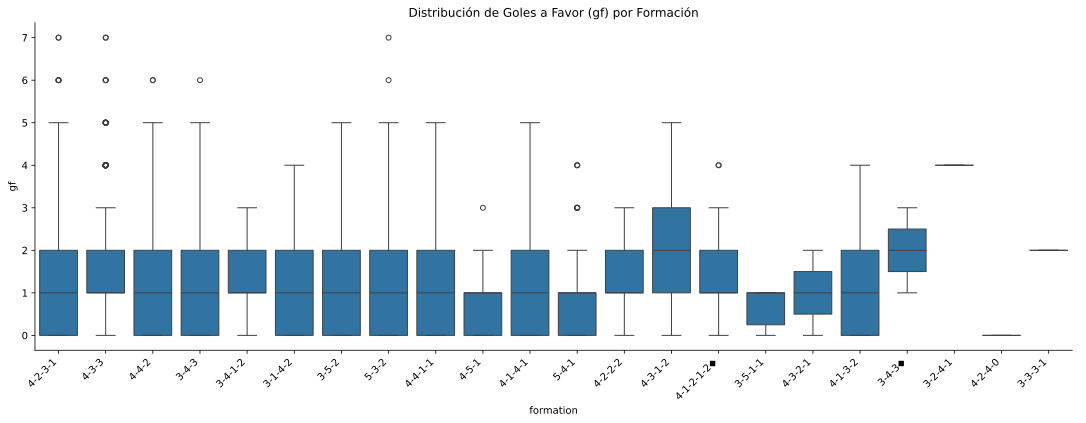

In [52]:
sns.catplot(x='formation', y='gf', data=df, kind='box', height=6, aspect=2.5)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Goles a Favor (gf) por Formación')
plt.tight_layout()
plt.show()

#### Explicación de los parámetros de `sns.catplot()` en el ejemplo

El método [`seaborn.catplot()`](https://seaborn.pydata.org/generated/seaborn.catplot.html) es una figura a nivel de facetas que se utiliza para visualizar relaciones entre una variable numérica y una o más variables categóricas. Puede ser una alternativa a `lmplot()` cuando se trabajan con variables categóricas. En el ejemplo anterior, se utiliza con los siguientes parámetros:

*   **`x='formation'`**: Especifica la variable categórica para el eje horizontal. Aquí, es la columna `'formation'` del DataFrame `df`, mostrando las diferentes formaciones utilizadas por los equipos.

*   **`y='gf'`**: Especifica la variable numérica para el eje vertical. En este caso, se utiliza `'gf'` (goles a favor), permitiendo ver la distribución de goles para cada formación.

*   **`data=df`**: Indica el DataFrame de Pandas del que se tomarán los datos.

*   **`kind='box'`**: Este parámetro determina el tipo de gráfico categórico a dibujar. Al usar `'box'`, se genera un diagrama de caja para la distribución de `'gf'` dentro de cada categoría de `'formation'`. Otras opciones comunes incluyen `'violin'`, `'bar'`, `'point'`, `'strip'`, `'swarm'`.

*   **`height=6`**: Establece la altura de cada faceta en pulgadas.

*   **`aspect=2.5`**: Factor de aspecto de cada faceta, lo que permite controlar el ancho relativo a la altura. Un valor de `2.5` hace que cada faceta sea 2.5 veces más ancha que alta, adecuado para mostrar muchas categorías sin superposición.

Adicionalmente, se utilizan funciones de `matplotlib.pyplot` para mejorar la legibilidad del gráfico:

*   **`plt.xticks(rotation=45, ha='right')`**: Rota las etiquetas del eje x 45 grados y las alinea a la derecha para evitar que se superpongan, especialmente útil cuando hay muchas categorías.

*   **`plt.title('Distribución de Goles a Favor (gf) por Formación')`**: Establece el título del gráfico.

*   **`plt.tight_layout()`**: Ajusta automáticamente los parámetros de la subtrama para que quepa en el área de la figura, evitando el solapamiento de elementos.

*   **`plt.show()`**: Muestra el gráfico generado.

#### 3.3 Categóricas-Categóricas

Como hemos visto previamente, el descriptor *Customer service calls* tiene pocos valores únicos que pueden ser considerados o bien como númericos o bien como ordinales. Ya hemos visto su distribución con un diagrama de barras. Ahora estamos interesados en la relación entre este descriptor ordinal y el descriptor *Churn*.

Vamos a ver la distribución del número de llamadas al servicio de atención al cliente, usando de nuevo un diagrama de barras, al cual le vamos a añadir el parámetro `hue=Churn` para añadir una dimensión categórica al diagrama.